<a href="https://colab.research.google.com/github/abhi01-sys/ML--Journey/blob/main/Logistic_Regression_GD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [74]:
from sklearn.datasets import make_classification

In [125]:
X,y = make_classification(n_samples = 100 , n_features=2, n_informative=1, n_redundant=0,n_classes = 2,n_clusters_per_class=1
                          ,random_state=41,hypercube=False,class_sep=20)

In [126]:
X

array([[ 0.51123145, -0.11697552],
       [ 0.06316371, -0.73115232],
       [-0.0425064 , -0.7081059 ],
       [-3.2891569 , -2.01199214],
       [ 0.1111445 ,  1.63493163],
       [-2.53070306,  0.15599044],
       [-3.49036198,  1.07782053],
       [ 0.3976447 ,  0.80626713],
       [-0.24666899,  0.74859527],
       [-3.65803446,  0.75152794],
       [-3.47658131, -0.90114581],
       [-3.47815037, -0.1815243 ],
       [ 0.29004249, -2.98092432],
       [ 1.11761831,  1.20500136],
       [-3.52530398,  0.78302407],
       [ 0.69929128,  0.42968688],
       [ 0.17089733, -0.73229726],
       [-3.57785124, -0.83930476],
       [ 0.12965489,  0.83727062],
       [-3.46888717, -0.10255323],
       [-3.97487212,  0.65867001],
       [-3.76348686,  0.92649819],
       [-3.01519735,  0.10216193],
       [ 1.92241659,  0.46886454],
       [-2.91479578,  0.45432938],
       [ 0.9259563 ,  1.8613386 ],
       [-3.4859014 , -0.79255991],
       [-2.73978345, -1.0004391 ],
       [-4.09896768,

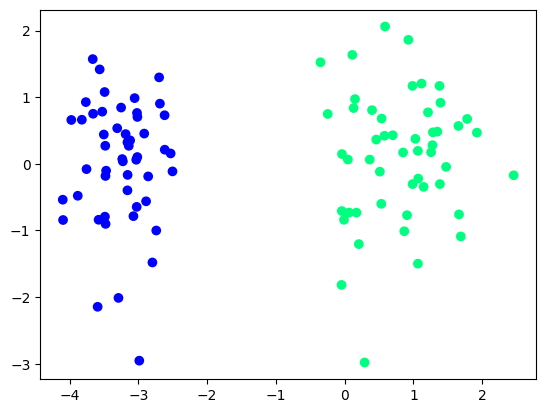

In [127]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter')

In [128]:
from sklearn.linear_model import LogisticRegression

In [129]:
lg = LogisticRegression(penalty=None,solver='sag')
lg.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [130]:
coef_ = lg.coef_

In [131]:
coef_

array([[4.81366904, 0.21845524]])

In [132]:
intercept_ = lg.intercept_

In [133]:
m1 = -(coef_[0][0]/coef_[0][1])
b1 = -(intercept_[0]/coef_[0][1])

In [134]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m1*x_input1 + b1

In [135]:
def sigmoid(x):
  return 1/(1+np.exp(-x))

In [142]:
def LG(X,y):
  X = np.insert(X,0,1 , axis = 1)
  weights = np.ones(X.shape[1])
  lr = 0.5

  for i in range(2500):
    y_hat = sigmoid(np.dot(X,weights))
    weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])

  return weights[1:],weights[0]



In [143]:
coef,intercept = LG(X,y)

In [144]:
coef

array([4.36410145, 0.17189254])

In [145]:
m = -(coef[0]/coef[1])
b = -(intercept/coef[1])

In [146]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

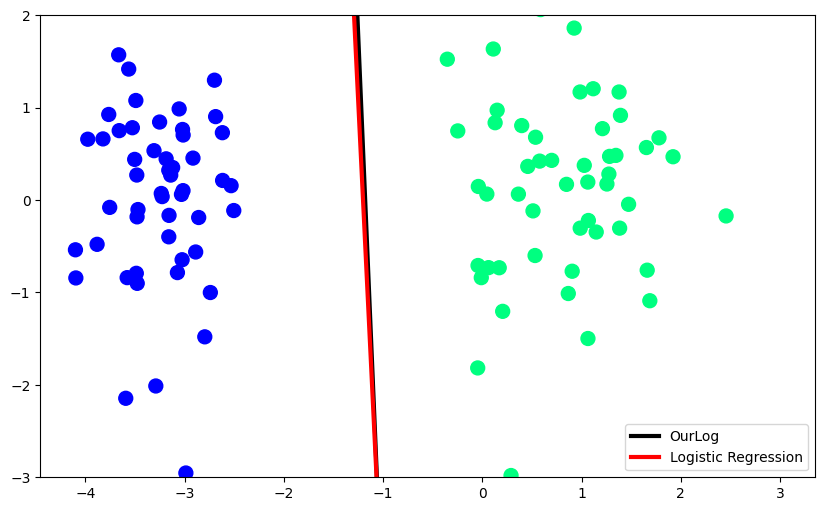

In [147]:
plt.figure(figsize = (10,6))
plt.plot(x_input,y_input,color='black',linewidth = 3)
plt.plot(x_input1,y_input1,color='red',linewidth = 3)
plt.scatter(X[:,0],X[:,1],c=y,cmap = 'winter',s=100)
plt.legend(['OurLog','Logistic Regression',],loc = 'lower right')
plt.ylim(-3,2)